Plot saved to ESS_Sensitivity_Plot.png


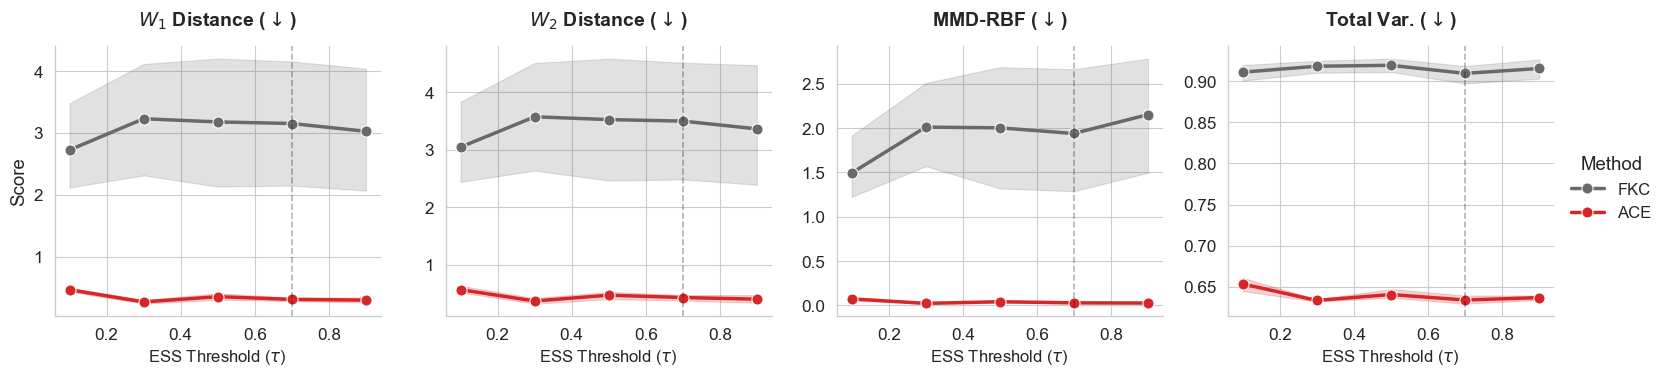

In [3]:
import pandas as pd
# !pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
import io

# ==========================================
# 1. LOAD DATA
# ==========================================
csv_data = """seed,method,W1,W2,MMD_RBF,Total Var.,A,B,ESS_Threshold
0,FKC,2.671122276924688,2.958711624716925,1.267066478729248,0.9104000000000001,1,1,0.1
0,ACE,0.45108392028256944,0.5294060959511929,0.09096813201904297,0.6539,1,1,0.1
0,FKC,3.4695492583910754,3.7952742631138228,1.7368170022964478,0.9193060491493384,1,1,0.3
0,ACE,0.2837551553082389,0.39101061972767515,0.026133954524993896,0.6348877853424109,1,1,0.3
0,FKC,2.635403127283796,2.9104787290369014,1.4934245347976685,0.9286786924939467,1,1,0.5
0,ACE,0.4462359031293904,0.5690063408124068,0.06979155540466309,0.6533240506329114,1,1,0.5
0,FKC,2.5580212045630644,2.8336678031973097,1.5015771389007568,0.9128231367169639,1,1,0.7
0,ACE,0.3362470547979451,0.4870415253971988,0.032257080078125,0.6351821164232847,1,1,0.7
0,FKC,2.383411665109474,2.6509240935734875,2.8717684745788574,0.93428920889537,1,1,0.9
0,ACE,0.37758675580423,0.5337254428397956,0.03982508182525635,0.6391539055449713,1,1,0.9
1,FKC,4.2284852264504345,4.585312101147793,2.3089380264282227,0.9195476532302596,1,1,0.1
1,ACE,0.4316968612763876,0.5378348636978592,0.07085424661636353,0.6533617661816358,1,1,0.1
2,FKC,1.930929985235221,2.276854818614506,1.1867969036102295,0.8915554360353439,1,1,0.1
2,ACE,0.4297983665602693,0.4962915973295295,0.0813295841217041,0.6556402243589743,1,1,0.1
3,FKC,2.004467736415929,2.3474785539773624,1.4649248123168945,0.909593657086224,1,1,0.1
3,ACE,0.5242704349986455,0.7009764740865341,0.03785830736160278,0.6377822764552911,1,1,0.1
4,FKC,2.7904990279800783,3.064268541298036,1.2418321371078491,0.925,1,1,0.1
4,ACE,0.4819212066345991,0.5788725075984056,0.0894121527671814,0.6654519356460533,1,1,0.1
1,FKC,4.547946963459682,4.921675030264583,2.8481316566467285,0.9297020820575628,1,1,0.3
1,ACE,0.2236679396480153,0.3075014204955778,0.018775463104248047,0.6322165849264338,1,1,0.3
2,FKC,2.0499435269531423,2.3533058824504858,1.586472511291504,0.9040960521121201,1,1,0.3
2,ACE,0.3237596034523107,0.4695252829295255,0.030008435249328613,0.6353644657863146,1,1,0.3
3,FKC,2.0004597852714214,2.344475139888799,1.4729975461959839,0.9182887445887447,1,1,0.3
3,ACE,0.25836356265242777,0.3714566058171081,0.020724594593048096,0.6320083083083083,1,1,0.3
4,FKC,4.084050908036088,4.450108195686759,2.4135093688964844,0.9208823529411765,1,1,0.3
4,ACE,0.24392678933833567,0.32033378496137577,0.021965444087982178,0.6313572864321608,1,1,0.3
1,FKC,4.565417691592315,4.939379009426702,2.8578455448150635,0.9235714372346877,1,1,0.5
1,ACE,0.347686367670207,0.48201250023863923,0.03843808174133301,0.6384377964575203,1,1,0.5
2,FKC,2.0269332292908295,2.370237978907089,1.1330214738845825,0.9078942710560067,1,1,0.5
2,ACE,0.37930631694566846,0.5050826542387004,0.04530757665634155,0.6368671679197995,1,1,0.5
3,FKC,1.987620273176426,2.3376318451993527,1.4207051992416382,0.9090190766108575,1,1,0.5
3,ACE,0.3156302133448867,0.451838641030446,0.02883732318878174,0.6356397111913357,1,1,0.5
4,FKC,4.680488438897764,5.0621037885062945,3.112687349319458,0.9286780976220275,1,1,0.5
4,ACE,0.2686304438141428,0.3546417513669526,0.0268593430519104,0.6375121121121121,1,1,0.5
1,FKC,4.4482112878494116,4.815448088293516,2.644001007080078,0.9214455953016552,1,1,0.7
1,ACE,0.26522724981493073,0.36215999959056405,0.022831201553344727,0.6282914891489149,1,1,0.7
2,FKC,2.1187640176370395,2.467563381293868,1.0419046878814697,0.8853414075286417,1,1,0.7
2,ACE,0.34453142230727757,0.4992698123291965,0.034919679164886475,0.6449338737115982,1,1,0.7
3,FKC,1.9767251619131003,2.3259969709536645,1.4283051490783691,0.9098335427742871,1,1,0.7
3,ACE,0.27452820674935186,0.3820974920280395,0.023885250091552734,0.6295593890836255,1,1,0.7
4,FKC,4.665837171434316,5.047875703377264,3.082986354827881,0.9192302904564315,1,1,0.7
4,ACE,0.3195528769562292,0.429236009123164,0.033013999462127686,0.6304146031428285,1,1,0.7
1,FKC,4.065684461611906,4.411413775700504,2.0091426372528076,0.9173573382430299,1,1,0.9
1,ACE,0.2973141426818991,0.4007880775002392,0.02447342872619629,0.6309641962944417,1,1,0.9
2,FKC,1.98012851415699,2.3221128230509764,1.3376667499542236,0.8948727272727273,1,1,0.9
2,ACE,0.2671305754103127,0.3840582329066812,0.022841036319732666,0.6349198278450605,1,1,0.9
3,FKC,1.9941951706572165,2.335591893648943,1.3994040489196777,0.9083838741396264,1,1,0.9
3,ACE,0.23806422919997175,0.3010554298584418,0.021109402179718018,0.6375040844929423,1,1,0.9
4,FKC,4.713815317336253,5.092829365058878,3.1451077461242676,0.9236224852071007,1,1,0.9
4,ACE,0.29863210080212105,0.39866761067141593,0.027861177921295166,0.6401947817360762,1,1,0.9
"""

df = pd.read_csv(io.StringIO(csv_data))

# ==========================================
# 2. CONFIG & STYLE
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif', 'serif']
sns.set_context("paper", font_scale=1.4)
sns.set_style("whitegrid")

METRIC_LABELS = {
    'W1': r'$W_1$ Distance ($\downarrow$)',
    'W2': r'$W_2$ Distance ($\downarrow$)',
    'MMD_RBF': r'MMD-RBF ($\downarrow$)',
    'Total Var.': r'Total Var. ($\downarrow$)'
}

PALETTE = {
    'FKC': '#696969',  # Dark Gray
    'ACE': '#D62728'   # Bold Red
}

# ==========================================
# 3. PLOT GENERATION
# ==========================================
def plot_ess_sensitivity(df):
    # Melt for plotting
    df_melted = df.melt(
        id_vars=['ESS_Threshold', 'method'], 
        value_vars=['W1', 'W2', 'MMD_RBF', 'Total Var.'],
        var_name='Metric', value_name='Score'
    )

    # Create Grid
    g = sns.FacetGrid(df_melted, col='Metric', hue='method', 
                      sharey=False, height=4, aspect=1.0, palette=PALETTE)
    
    g.map(sns.lineplot, 'ESS_Threshold', 'Score', marker='o', linewidth=2.5, markersize=8)

    # Customize
    for ax, title in zip(g.axes.flat, ['W1', 'W2', 'MMD_RBF', 'Total Var.']):
        ax.set_title(METRIC_LABELS[title], fontweight='bold', fontsize=14, pad=15)
        ax.set_xlabel(r"ESS Threshold ($\tau$)", fontsize=12)
        
        # Highlight 0.7 as the chosen operating point
        ax.axvline(x=0.7, color='black', linestyle='--', alpha=0.3)

    # Add Legend manually to ensure placement
    g.add_legend(title="Method", fontsize=12, title_fontsize=12)
    
    plt.subplots_adjust(top=0.85)
    # g.fig.suptitle("Sensitivity to Resampling Threshold (ESS)", 
                #    fontsize=16, fontweight='bold', fontfamily='serif')
    
    plt.savefig("ESS_Sensitivity_Plot.png", dpi=300, bbox_inches='tight')
    print("Plot saved to ESS_Sensitivity_Plot.png")
    plt.show()

# ==========================================
# 4. LATEX TABLE GENERATION
# ==========================================
def generate_latex_table(df):
    # Pivot to get side-by-side columns for methods
    pivot_df = df.pivot(index='ESS_Threshold', columns='method', values=['W1', 'W2', 'MMD_RBF', 'Total Var.'])
    
    print("\n=== LaTeX Table Code ===")
    print(r"\begin{table}[h]")
    print(r"\centering")
    print(r"\caption{Performance comparison across varying ESS Thresholds. \textbf{Bold} indicates the best method.}")
    print(r"\label{tab:ess_ablation}")
    print(r"\begin{tabular}{c|cc|cc|cc}")
    print(r"\toprule")
    print(r"ESS & \multicolumn{2}{c|}{$W_1 (\downarrow)$} & \multicolumn{2}{c|}{$W_2 (\downarrow)$} & \multicolumn{2}{c}{MMD (\downarrow)$} \\")
    print(r"Threshold & FKC & ACE & FKC & ACE & FKC & ACE \\")
    print(r"\midrule")

    for ess in pivot_df.index:
        row = pivot_df.loc[ess]
        line = f"{ess:.1f}"
        
        # We only showing W1, W2, MMD for brevity in table (TV is often omitted in main text tables)
        # You can add 'Total Var.' back if needed
        for metric in ['W1', 'W2', 'MMD_RBF']:
            fkc_val = row[(metric, 'FKC')]
            ace_val = row[(metric, 'ACE')]
            
            fkc_str = f"{fkc_val:.3f}"
            ace_str = f"{ace_val:.3f}"
            
            if fkc_val < ace_val:
                fkc_str = f"\\textbf{{{fkc_str}}}"
            else:
                ace_str = f"\\textbf{{{ace_str}}}"
            
            line += f" & {fkc_str} & {ace_str}"
        
        line += r" \\"
        print(line)
        
    print(r"\bottomrule")
    print(r"\end{tabular}")
    print(r"\end{table}")

# Run
plot_ess_sensitivity(df)
# generate_latex_table(df)